# Importing Libraries

In [7]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Loading the model

In [11]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
])

caltech101_dataset = datasets.Caltech101(root='../caltech_data', download=False, transform=transform)

test_loader = DataLoader(caltech101_dataset, batch_size=1, shuffle=True)

NUM_CLASSES = 101

In [12]:
def load_resnet34(weights_path, num_classes=NUM_CLASSES, device=device):

    model = models.resnet34(weights=None)
    
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    
    checkpoint = torch.load(weights_path, map_location=device)
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        model.load_state_dict(checkpoint["state_dict"])
    elif isinstance(checkpoint, dict):
        model.load_state_dict(checkpoint)
    else:
        model = checkpoint

    model = model.to(device)
    model.eval()
    return model


def load_mobilenet_v2(weights_path, num_classes=NUM_CLASSES, device=device):
    model = models.mobilenet_v2(weights=None)
    
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    
    checkpoint = torch.load(weights_path, map_location=device)
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        model.load_state_dict(checkpoint["state_dict"])
    elif isinstance(checkpoint, dict):
        model.load_state_dict(checkpoint)
    else:
        model = checkpoint

    model = model.to(device)
    model.eval()
    return model

In [13]:
resnet34_path = "../Phase1/resnet34_caltech101.pth"
mobilenet_path = "../Phase1/mobilenetv2_caltech101.pth"


resnet34_model = load_resnet34(resnet34_path)
print("ResNet-34 successfully loaded")

mobilenet_model = load_mobilenet_v2(mobilenet_path)
print("MobileNetV2 successfully loaded")

ResNet-34 successfully loaded
MobileNetV2 successfully loaded


# Saliency Map

In [ ]:
def generate_saliency_map(model, image, target_class=None):
    # Puts the model in testing mode
    model.eval()
    
    # Clone and detach the image to create a clean leaf tensor, 
    # then explicitly require gradients for it.
    img_tensor = image.clone().detach().requires_grad_(True)
    
    # Forward pass
    output = model(img_tensor)
    
    # If no target class is specified, use the model's top prediction
    if target_class is None:
        target_class = output.argmax(dim=1).item()
        
    # Get the specific score for the target class
    score = output[0, target_class]
    
    # Clear previous gradients and run backward pass
    model.zero_grad()
    score.backward()
    
    # Extract the gradients of the input image
    gradients = img_tensor.grad.data.abs().squeeze()
    
    # Take the maximum across the 3 color channels to get a single 2D map
    saliency, _ = torch.max(gradients, dim=0)
    
    # Normalize the map between 0 and 1 for clean visualization
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min())
    
    return saliency.cpu().numpy()

In [ ]:
def visualize_saliency(original_image_tensor, saliency_map, title="Saliency Map"):
    
    # Convert image tensor back to numpy for matplotlib
    # Assuming the tensor is (1, 3, 224, 224) and values are [0, 1]
    img = original_image_tensor.squeeze().detach().cpu().numpy()
    img = np.transpose(img, (1, 2, 0)) # Change to (H, W, C)
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    
    ax[0].imshow(img)
    ax[0].set_title("Original Image")
    ax[0].axis('off')
    
    # Plot the saliency map using a heatmap colormap (e.g., 'hot' or 'jet')
    im = ax[1].imshow(saliency_map, cmap='hot')
    ax[1].set_title(title)
    ax[1].axis('off')
    
    plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
    plt.show()

In [16]:
def fgsm_attack(image, epsilon, data_grad):
    # Get the direction of the gradient (either +1 or -1 for every pixel)
    sign_data_grad = data_grad.sign()
    
    # Multiply by epsilon (attack strength) and add to the original image
    # Adds "noise" to the image
    perturbed_image = image + epsilon * sign_data_grad
    
    return perturbed_image

--- Analyzing Clean Image ---
True Label: 1 | Model Prediction: 1


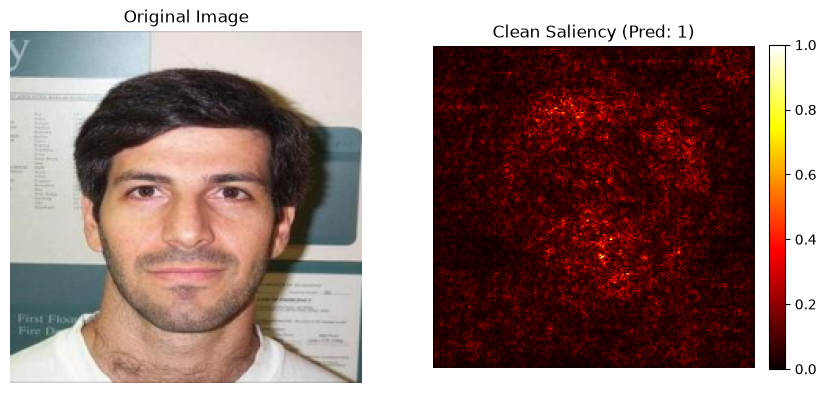

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13039216..1.15].



--- Applying FGSM Attack ---
--- Analyzing Adversarial Image ---
True Label: 1 | New Model Prediction: 0


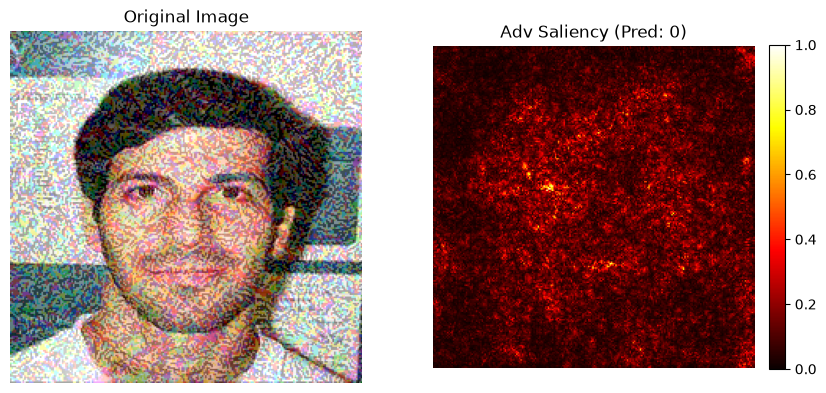

In [ ]:
# Grab a single image and label from the test loader
data_iter = iter(test_loader)
image, target = next(data_iter)
image, target = image.to(device), target.to(device)

# Choose which model to test
model_to_test = resnet34_model
model_to_test.eval()

# ---------------------------------------------------------
# 1. Test Saliency on the CLEAN Image
# ---------------------------------------------------------
print("--- Analyzing Clean Image ---")
# Get the model's prediction for the clean image
output_clean = model_to_test(image)
pred_clean = output_clean.max(1, keepdim=True)[1].item()
print(f"True Label: {target.item()} | Model Prediction: {pred_clean}")

# Generate and visualize the saliency map
saliency_clean = generate_saliency_map(model_to_test, image, target_class=pred_clean)
visualize_saliency(image, saliency_clean, title=f"Clean Saliency (Pred: {pred_clean})")

# ---------------------------------------------------------
# 2. Generate Adversarial Image
# ---------------------------------------------------------
print("\n--- Applying FGSM Attack ---")
epsilon = 0.15 # Using a strength we know breaks the model
image.requires_grad = True

# Calculate loss and gradients for the attack
output = model_to_test(image)
loss = F.cross_entropy(output, target)
model_to_test.zero_grad()
loss.backward()
data_grad = image.grad.data

# Apply the attack
adv_image = fgsm_attack(image, epsilon, data_grad)

# ---------------------------------------------------------
# 3. Test Saliency on the ADVERSARIAL Image
# ---------------------------------------------------------
print("--- Analyzing Adversarial Image ---")
# Get the model's new prediction for the attacked image
output_adv = model_to_test(adv_image)
pred_adv = output_adv.max(1, keepdim=True)[1].item()
print(f"True Label: {target.item()} | New Model Prediction: {pred_adv}")

# Generate and visualize the saliency map for the attacked image
saliency_adv = generate_saliency_map(model_to_test, adv_image, target_class=pred_adv)
visualize_saliency(adv_image, saliency_adv, title=f"Adv Saliency (Pred: {pred_adv})")